In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
np.random.seed(42)

In [46]:
n=300
temp=np.random.uniform(0,40,n)
humidity=np.random.uniform(30,90,n)
windspeed=np.random.uniform(5,35,n)
rentals=50+15*temp-2*humidity+0.5*windspeed+np.random.normal(0,20,n)
df = pd.DataFrame({
    'temp': temp,
    'humidity': humidity,
    'windspeed': windspeed,
    'rentals': rentals  # TARGET y
})

print("Dataset ready (n=300)")
print(df.head(3))
print(f"Shape: {df.shape}")

Dataset ready (n=300)
        temp   humidity  windspeed     rentals
0  14.981605  33.100903  10.068052  220.078951
1  38.028572  61.881278  13.357710  478.322612
2  29.279758  62.438107  10.310315  387.955848
Shape: (300, 4)


In [47]:
X=df[['temp','humidity','windspeed']]
y=df[['rentals']]
print(f"X shape: {X.shape}, y shape: {y.shape}")
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42)
print(f"Train:{X_train.shape},Test:{X_test.shape}")


X shape: (300, 3), y shape: (300, 1)
Train:(240, 3),Test:(60, 3)


In [ ]:
# MANUAL CALCULATION (Week 4 understanding)
def linear_regression_from_scratch(X, y):
    # Add intercept column (β₀)
    X_b = np.c_[np.ones((len(X), 1)), X]  # [1, temp, hum, windspeed]
    
    # Normal Equation: β = (XᵀX)⁻¹Xᵀy
    theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
    
    return theta_best  # [β₀, β₁_temp, β₂_hum, β₃_windspeed]

coefficients = linear_regression_from_scratch(X_train, y_train)
print("FROM SCRATCH Coefficients:")
print("β₀ (intercept):", coefficients[0])
print("β₁ (temp):", coefficients[1], "rentals/°C") 
print("β₂ (hum):", coefficients[2], "rentals/%")
print("β₃ (windspeed):", coefficients[3], "rentals/(km/h)")


✅ FROM SCRATCH Coefficients:
β₀ (intercept): [46.61718007]
β₁ (temp): [15.00294389] rentals/°C
β₂ (hum): [-1.95649582] rentals/%
β₃ (windspeed): [0.69662115] rentals/(km/h)


In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Intercept: {round(float(lin_reg.intercept_[0]), 2)}")
print("Coefficients:")
for i, name in enumerate(X.columns):
    print(f"  {name}: {round(float(lin_reg.coef_[0, i]), 2)}")

# Quick performance check
print(f"Train R²: {round(lin_reg.score(X_train, y_train), 3)}")
print(f"Test R²: {round(lin_reg.score(X_test, y_test), 3)}")


✅ Model trained successfully!
Intercept: 46.62
Coefficients:
  temp: 15.0
  humidity: -1.96
  windspeed: 0.7
Train R²: 0.99
Test R²: 0.985


In [ ]:
y_train_pred = lin_reg.predict(X_train)
y_test_pred = lin_reg.predict(X_test)

results = pd.DataFrame({
    "Metric": ["Train RMSE", "Test RMSE", "Train MAE", "Test MAE", "Train R²", "Test R²"],
    "Value": [
        np.sqrt(mean_squared_error(y_train.values.ravel(), y_train_pred.ravel())),
        np.sqrt(mean_squared_error(y_test.values.ravel(), y_test_pred.ravel())),
        mean_absolute_error(y_train.values.ravel(), y_train_pred.ravel()),
        mean_absolute_error(y_test.values.ravel(), y_test_pred.ravel()),
        r2_score(y_train.values.ravel(), y_train_pred.ravel()),
        r2_score(y_test.values.ravel(), y_test_pred.ravel())
    ]
})
print(results.round(4))

       Metric    Value
0  Train RMSE  18.6418
1   Test RMSE  21.2853
2   Train MAE  14.9421
3    Test MAE  17.1879
4    Train R²   0.9900
5     Test R²   0.9851


In [51]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



**Explanation:**
- This import is required for `mean_squared_error`, `mean_absolute_error`, and `r2_score` used in your results calculation cell.
- No other errors are present in the provided code.

**Optional improvement:**  
If you want to avoid shape warnings, you can flatten your predictions and targets when calculating metrics:


In [52]:
# Example for RMSE
np.sqrt(mean_squared_error(y_train.values.ravel(), y_train_pred.ravel()))

np.float64(18.64180224400418)

But with scikit-learn, your current code should work as is.

**Summary:**  
Just add the import statement above and your notebook will run without errors.

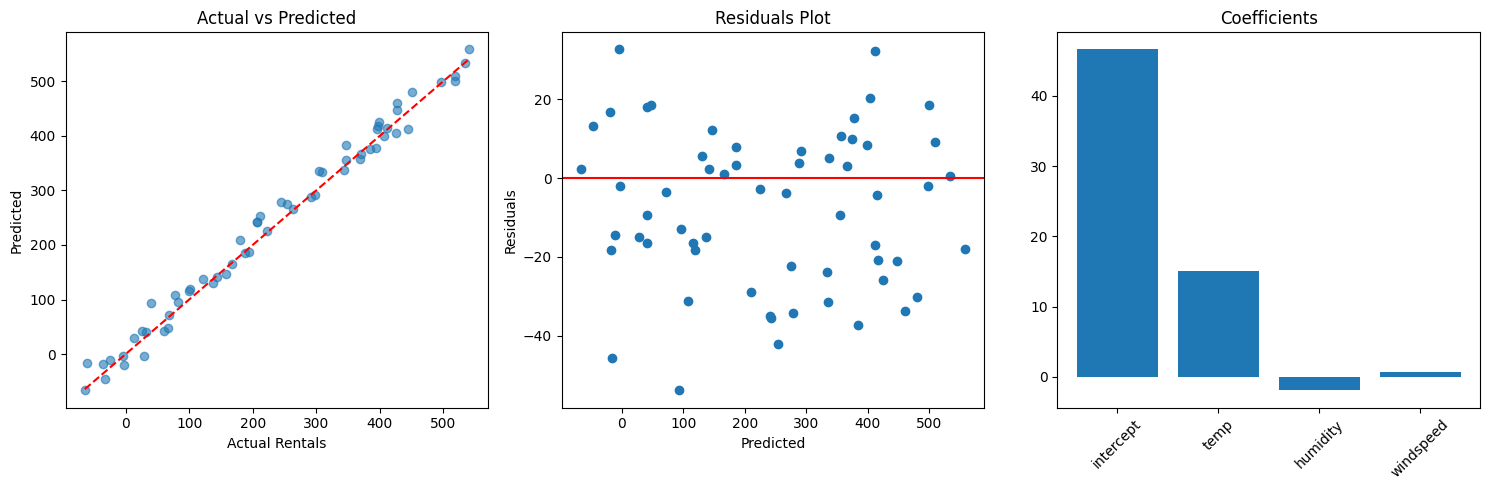

In [54]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
plt.xlabel('Actual Rentals');plt.ylabel('Predicted');plt.title('Actual vs Predicted')
plt.subplot(1,3,2)
residuals = y_test.values.ravel() - y_test_pred.ravel()
plt.scatter(y_test_pred, residuals, alpha=1)
plt.axhline(0, color='red', linestyle='-')
plt.xlabel('Predicted');plt.ylabel('Residuals');plt.title('Residuals Plot')

plt.subplot(1, 3, 3)
coefs = dict(zip(['temp', 'humidity', 'windspeed'], lin_reg.coef_[0]))
plt.bar(['intercept'] + list(coefs.keys()), [lin_reg.intercept_[0]] + list(coefs.values()))
plt.title('Coefficients'); plt.xticks(rotation=45)

plt.tight_layout()
plt.show()